# Customer Churn Prediction & Retention Analytics

## Project Overview

This project analyzes customer churn in the telecommunications industry and develops machine learning models to predict which customers are at risk of leaving.

### Objectives
- Explore customer demographics, services, contracts, and billing information.
- Identify the factors associated with customer churn.
- Prepare the data for machine learning.
- Build and evaluate churn prediction models.
- Generate actionable customer retention recommendations.

In [208]:
import pandas as pd

In [209]:
df = pd.read_excel("../data/Telco_customer_churn.xlsx")

## 1. Initial Data Inspection

Let's inspect the dataset structure, dimensions, and available variables before performing data cleaning or analysis.

In [210]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [211]:
df.shape

(7043, 33)

In [212]:
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='str')

## 2. Data Quality Assessment

Before analyzing customer churn, we will examine the dataset's data types and identify missing values that may require cleaning.

In [213]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

In [214]:
df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [215]:
df.isnull().sum().sort_values(ascending=False)

Churn Reason         5174
CustomerID              0
Count                   0
State                   0
Country                 0
Zip Code                0
Lat Long                0
Latitude                0
City                    0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Longitude               0
Internet Service        0
Online Security         0
Device Protection       0
Online Backup           0
Streaming TV            0
Streaming Movies        0
Contract                0
Tech Support            0
Paperless Billing       0
Payment Method          0
Total Charges           0
Monthly Charges         0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
dtype: int64

### Summary

The data-quality assessment helps identify columns with missing values, incorrect data types, or other issues that need to be addressed before exploratory analysis and model development.

## 3. Duplicate Record Check

We will check whether the dataset contains duplicate customer records before continuing with exploratory analysis.

In [216]:
df.duplicated().sum()

np.int64(0)

In [217]:
df["CustomerID"].duplicated().sum()

np.int64(0)

### Duplicate Check Summary

Duplicate records and duplicate customer IDs can distort analysis and machine learning results, so they should be identified before further processing.

## 4. Churn Distribution

The target variable, `Churn Label`, indicates whether a customer has left the telecommunications service. We will examine its distribution to understand the balance between churned and retained customers.

In [218]:
df["Churn Label"].value_counts()

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

In [219]:
df["Churn Label"].value_counts(normalize=True) * 100

Churn Label
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

<Axes: title={'center': 'Customer Churn Distribution'}, xlabel='Churn', ylabel='Number of Customers'>

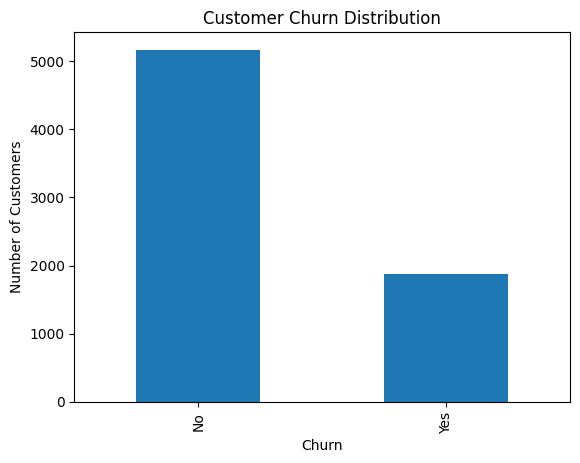

In [220]:
df["Churn Label"].value_counts().plot(
    kind="bar",
    title="Customer Churn Distribution",
    xlabel="Churn",
    ylabel="Number of Customers"
)

### Churn Distribution Summary

The churn distribution provides the baseline for understanding customer retention and identifying whether the target variable is balanced or imbalanced.

## 5. Churn by Contract Type

Contract duration can influence customer retention. We will compare churn rates across different contract types to identify whether customers on short-term contracts are more likely to leave.

In [221]:
pd.crosstab(
    df["Contract"],
    df["Churn Label"],
    normalize="index"
) * 100

Churn Label,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


<Axes: title={'center': 'Churn Rate by Contract Type'}, xlabel='Contract Type', ylabel='Churn Rate (%)'>

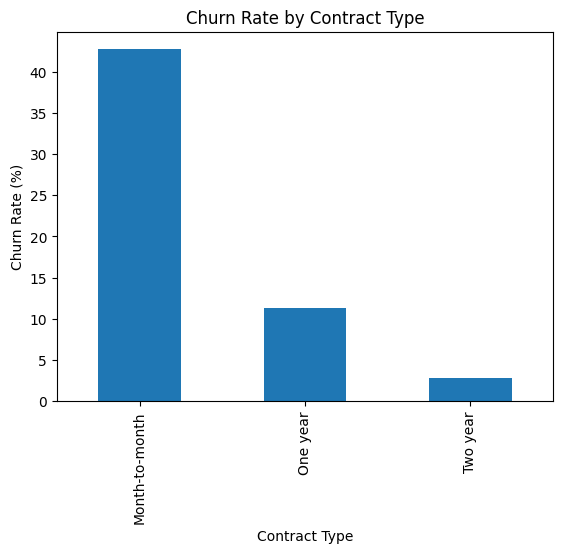

In [222]:
churn_by_contract = pd.crosstab(
    df["Contract"],
    df["Churn Label"],
    normalize="index"
) * 100

churn_by_contract["Yes"].plot(
    kind="bar",
    title="Churn Rate by Contract Type",
    xlabel="Contract Type",
    ylabel="Churn Rate (%)"
)

### Churn by Contract — Interpretation

The churn rates across contract types will help identify which customer groups have greater retention risk and where targeted retention strategies may be most effective.

## 6. Churn by Tenure

Customer tenure represents the number of months a customer has remained with the company. We will compare tenure distributions between churned and retained customers to determine whether newer or longer-tenured customers face greater churn risk.

In [223]:
df.groupby("Churn Label")["Tenure Months"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn Label,,,,,,,,
No,5174.0,37.569965,24.113777,0.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


In [224]:
df.groupby("Churn Label")["Tenure Months"].median()

Churn Label
No     38.0
Yes    10.0
Name: Tenure Months, dtype: float64

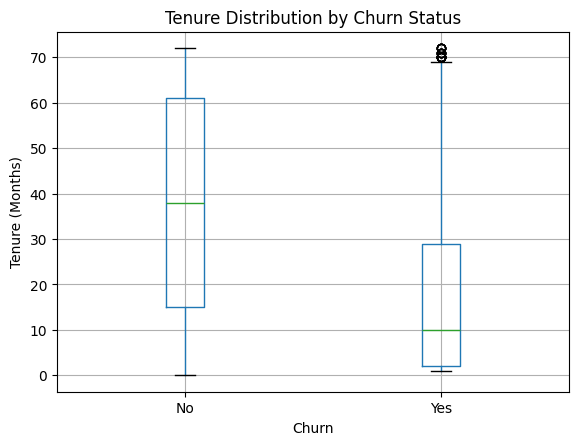

In [225]:
df.boxplot(
    column="Tenure Months",
    by="Churn Label"
)

import matplotlib.pyplot as plt

plt.title("Tenure Distribution by Churn Status")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")
plt.show()

### Tenure Analysis — Interpretation

Comparing tenure between churned and retained customers helps determine whether customer longevity is associated with retention. A lower tenure among churned customers may indicate that newer customers require stronger onboarding and early-stage retention efforts.

## 7. Churn by Monthly Charges

Monthly charges represent the customer's recurring service cost. We will compare monthly charges between churned and retained customers to determine whether pricing or higher recurring costs are associated with churn.

In [226]:
df.columns.tolist()

['CustomerID',
 'Count',
 'Country',
 'State',
 'City',
 'Zip Code',
 'Lat Long',
 'Latitude',
 'Longitude',
 'Gender',
 'Senior Citizen',
 'Partner',
 'Dependents',
 'Tenure Months',
 'Phone Service',
 'Multiple Lines',
 'Internet Service',
 'Online Security',
 'Online Backup',
 'Device Protection',
 'Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Contract',
 'Paperless Billing',
 'Payment Method',
 'Monthly Charges',
 'Total Charges',
 'Churn Label',
 'Churn Value',
 'Churn Score',
 'CLTV',
 'Churn Reason']

In [227]:
[col for col in df.columns if "charge" in col.lower()]

['Monthly Charges', 'Total Charges']

In [228]:
df.groupby("Churn Label")["Monthly Charges"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn Label,,,,,,,,
No,5174.0,61.265124,31.092648,18.25,25.10,64.425,88.4,118.75
Yes,1869.0,74.441332,24.666053,18.85,56.15,79.650,94.2,118.35


In [229]:
df.groupby("Churn Label")["Monthly Charges"].median()

Churn Label
No     64.425
Yes    79.650
Name: Monthly Charges, dtype: float64

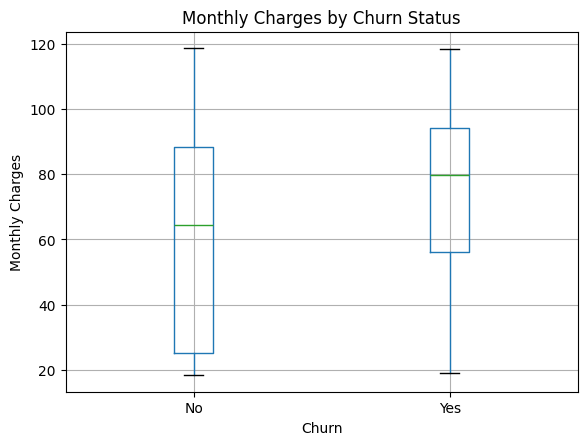

In [230]:
df.boxplot(
    column="Monthly Charges",
    by="Churn Label"
)

import matplotlib.pyplot as plt

plt.title("Monthly Charges by Churn Status")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

### Monthly Charges — Interpretation

Comparing monthly charges between churned and retained customers helps determine whether customers with higher recurring costs have greater churn risk. This can indicate a potential relationship between pricing, perceived value, and customer retention.

## 8. Churn by Internet Service

Internet service type may influence customer retention because different service technologies and offerings can provide different levels of value and customer satisfaction. We will compare churn rates across internet service categories.

In [231]:
churn_by_internet = pd.crosstab(
    df["Internet Service"],
    df["Churn Label"],
    normalize="index"
) * 100

churn_by_internet

Churn Label,No,Yes
Internet Service,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


<Axes: title={'center': 'Churn Rate by Internet Service'}, xlabel='Internet Service', ylabel='Churn Rate (%)'>

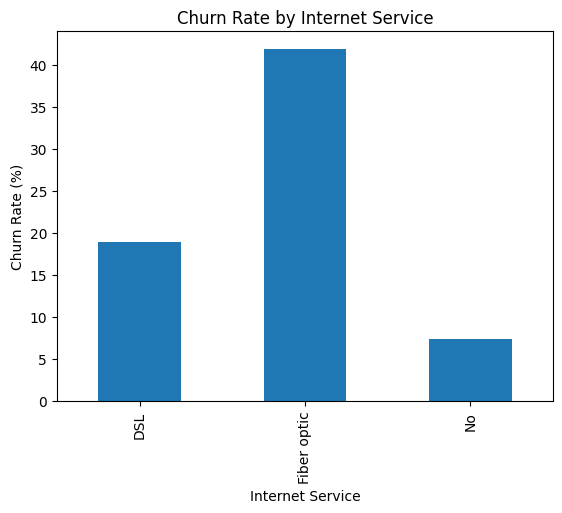

In [232]:
churn_by_internet["Yes"].plot(
    kind="bar",
    title="Churn Rate by Internet Service",
    xlabel="Internet Service",
    ylabel="Churn Rate (%)"
)

### Internet Service — Interpretation

Comparing churn rates across internet service types helps identify whether certain service categories are associated with higher customer attrition and may require targeted retention strategies.

## 9. Churn by Payment Method

Payment method can influence customer retention because different payment options may reflect different levels of convenience, commitment, and customer engagement. We will compare churn rates across payment methods.

In [233]:
churn_by_payment = pd.crosstab(
    df["Payment Method"],
    df["Churn Label"],
    normalize="index"
) * 100

churn_by_payment

Churn Label,No,Yes
Payment Method,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


<Axes: title={'center': 'Churn Rate by Payment Method'}, xlabel='Payment Method', ylabel='Churn Rate (%)'>

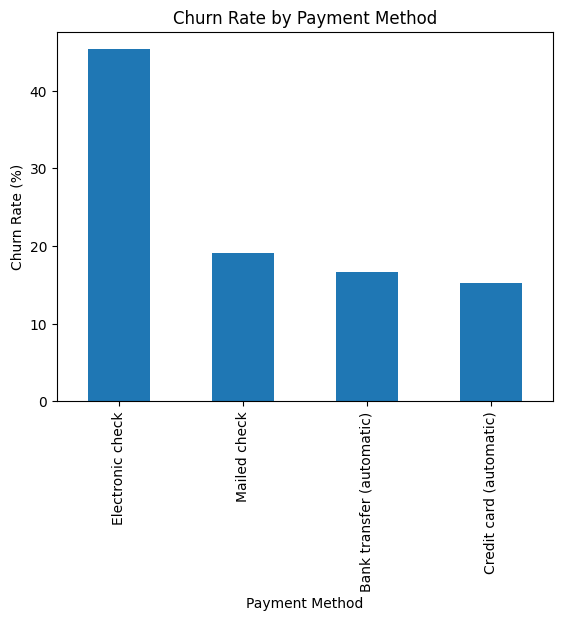

In [234]:
churn_by_payment["Yes"].sort_values(ascending=False).plot(
    kind="bar",
    title="Churn Rate by Payment Method",
    xlabel="Payment Method",
    ylabel="Churn Rate (%)"
)

### Payment Method — Interpretation

Comparing churn rates across payment methods can reveal whether particular payment behaviors are associated with higher customer attrition and may help identify opportunities for improving payment convenience or customer engagement.

## 10. Churn by Senior Citizen Status

Customer age may influence churn behavior. We will compare churn rates between senior and non-senior customers to identify whether senior customers represent a higher-risk segment.

In [235]:
churn_by_senior = pd.crosstab(
    df["Senior Citizen"],
    df["Churn Label"],
    normalize="index"
) * 100

churn_by_senior

Churn Label,No,Yes
Senior Citizen,,
No,76.393832,23.606168
Yes,58.318739,41.681261


<Axes: title={'center': 'Churn Rate by Senior Citizen Status'}, xlabel='Senior Citizen', ylabel='Churn Rate (%)'>

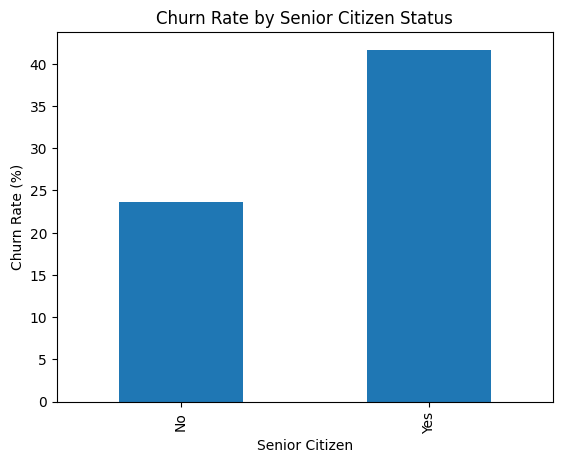

In [236]:
churn_by_senior["Yes"].plot(
    kind="bar",
    title="Churn Rate by Senior Citizen Status",
    xlabel="Senior Citizen",
    ylabel="Churn Rate (%)"
)

### Senior Citizen — Interpretation

Comparing churn rates by senior citizen status helps determine whether age-related differences should be considered when designing customer retention strategies.

## 11. Churn by Tech Support

Technical support availability may influence customer satisfaction and retention. We will compare churn rates between customers with and without technical support.

In [237]:
churn_by_support = pd.crosstab(
    df["Tech Support"],
    df["Churn Label"],
    normalize="index"
) * 100

churn_by_support

Churn Label,No,Yes
Tech Support,,
No,58.364526,41.635474
No internet service,92.595020,7.404980
Yes,84.833659,15.166341


<Axes: title={'center': 'Churn Rate by Tech Support'}, xlabel='Tech Support', ylabel='Churn Rate (%)'>

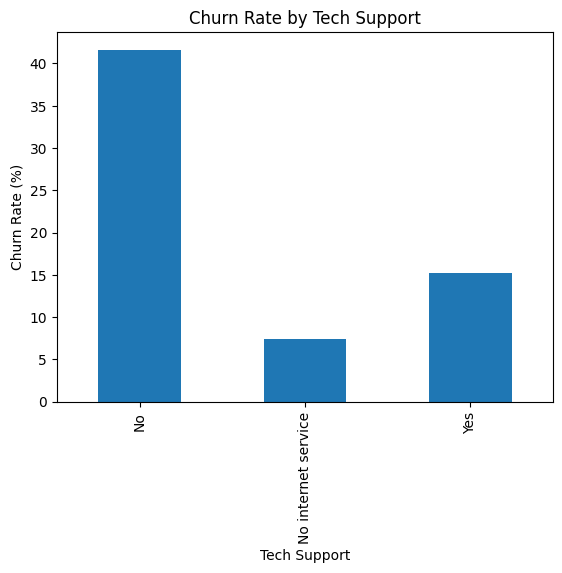

In [238]:
churn_by_support["Yes"].plot(
    kind="bar",
    title="Churn Rate by Tech Support",
    xlabel="Tech Support",
    ylabel="Churn Rate (%)"
)

### Tech Support — Interpretation

Comparing churn rates by technical support availability helps determine whether access to support services is associated with customer retention and whether support could be used as part of a retention strategy.

## 12. Churn by Online Security

Online security is an additional service offered to customers. We will compare churn rates across customers with and without this service to determine whether security-service adoption is associated with customer retention.

In [239]:
churn_by_security = pd.crosstab(
    df["Online Security"],
    df["Churn Label"],
    normalize="index"
) * 100

churn_by_security

Churn Label,No,Yes
Online Security,,
No,58.233276,41.766724
No internet service,92.595020,7.404980
Yes,85.388806,14.611194


<Axes: title={'center': 'Churn Rate by Online Security'}, xlabel='Online Security', ylabel='Churn Rate (%)'>

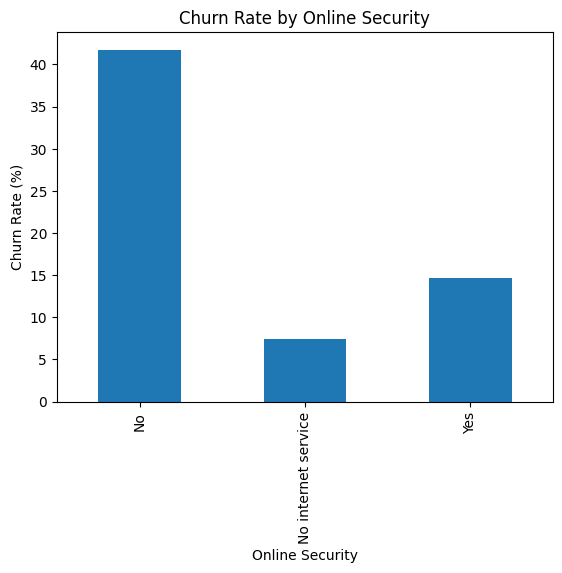

In [240]:
churn_by_security["Yes"].plot(
    kind="bar",
    title="Churn Rate by Online Security",
    xlabel="Online Security",
    ylabel="Churn Rate (%)"
)

### Online Security — Interpretation

Comparing churn rates by online security subscription can help determine whether additional service adoption is associated with customer retention and identify opportunities for targeted service bundles.

## 13. Key Exploratory Findings

The exploratory analysis identified several customer segments associated with higher churn risk:

- **Month-to-month contract customers** have substantially higher churn than customers on one-year or two-year contracts.
- **Churned customers have shorter tenure**, indicating that early-stage customers are particularly vulnerable to attrition.
- **Churned customers generally have higher monthly charges** than retained customers.
- **Fiber optic customers** have a substantially higher churn rate than DSL and customers without internet service.
- **Electronic check users** have the highest churn rate among payment methods.
- **Senior customers** show a higher churn rate than non-senior customers.
- Customers **without Tech Support** have considerably higher churn than customers with the service.
- Customers **without Online Security** also show substantially higher churn.

These findings will guide feature selection and provide a business context for the predictive modeling stage.

## 14. Preparing Data for Machine Learning

Before building predictive models, we need to select appropriate features, remove variables that could cause data leakage, encode categorical variables, and separate the predictors from the target variable.

## 15. Feature Selection and Data Leakage Prevention

For predictive modeling, only information that would reasonably be available before a customer churns should be used as a feature.

The dataset contains several fields that describe, score, or result from churn behavior. These fields will be excluded to prevent data leakage and ensure that model performance reflects a realistic prediction scenario.

In [241]:
leakage_and_irrelevant = [
    "CustomerID",
    "Count",
    "Country",
    "State",
    "City",
    "Zip Code",
    "Lat Long",
    "Latitude",
    "Longitude",
    "Churn Value",
    "Churn Score",
    "CLTV",
    "Churn Reason"
]

In [242]:
[col for col in leakage_and_irrelevant if col in df.columns]

['CustomerID',
 'Count',
 'Country',
 'State',
 'City',
 'Zip Code',
 'Lat Long',
 'Latitude',
 'Longitude',
 'Churn Value',
 'Churn Score',
 'CLTV',
 'Churn Reason']

In [243]:
model_df = df.drop(columns=leakage_and_irrelevant)

In [244]:
model_df.columns.tolist()

['Gender',
 'Senior Citizen',
 'Partner',
 'Dependents',
 'Tenure Months',
 'Phone Service',
 'Multiple Lines',
 'Internet Service',
 'Online Security',
 'Online Backup',
 'Device Protection',
 'Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Contract',
 'Paperless Billing',
 'Payment Method',
 'Monthly Charges',
 'Total Charges',
 'Churn Label']

### Feature Selection Summary

The modeling dataset excludes customer identifiers, constant or geographic fields, and churn-derived variables that could introduce data leakage.

The remaining variables represent customer demographics, tenure, subscribed services, contract characteristics, billing information, and the churn outcome.

In [245]:
model_df.shape

(7043, 20)

## 16. Separating Features and Target

The `Churn Label` column is the target variable we want to predict. All remaining columns will be used as potential predictors.

For machine learning, the target will be encoded as:
- `Yes` = 1, representing churn
- `No` = 0, representing retention

In [246]:
X = model_df.drop(columns=["Churn Label"])
y = model_df["Churn Label"].map({"Yes": 1, "No": 0})

In [247]:
X.shape, y.shape

((7043, 19), (7043,))

In [248]:
y.value_counts()

Churn Label
0    5174
1    1869
Name: count, dtype: int64

In [249]:
X.dtypes

Gender                   str
Senior Citizen           str
Partner                  str
Dependents               str
Tenure Months          int64
Phone Service            str
Multiple Lines           str
Internet Service         str
Online Security          str
Online Backup            str
Device Protection        str
Tech Support             str
Streaming TV             str
Streaming Movies         str
Contract                 str
Paperless Billing        str
Payment Method           str
Monthly Charges      float64
Total Charges         object
dtype: object

### Feature and Target Separation Summary

The dataset now contains 19 predictor variables and one binary target variable. The target has been encoded numerically so that it can be used for classification modeling.

The next stage will prepare the categorical and numerical features for machine learning.

## 17. Train-Test Split

The dataset will be divided into training and testing sets before preprocessing.

The training set will be used to fit the preprocessing steps and machine learning models, while the test set will be reserved for final model evaluation.

Stratified sampling will be used to preserve the proportion of churned and retained customers in both sets.

In [250]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [251]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((5634, 19), (1409, 19), (5634,), (1409,))

In [252]:
y_train.value_counts(normalize=True) * 100

Churn Label
0    73.464679
1    26.535321
Name: proportion, dtype: float64

In [253]:
y_test.value_counts(normalize=True) * 100

Churn Label
0    73.456352
1    26.543648
Name: proportion, dtype: float64

### Train-Test Split Summary

The data has been divided into training and testing sets using stratified sampling. The training set will be used for model development, while the unseen test set will be used for final performance evaluation.

## 18. Feature Preprocessing

Machine learning algorithms require numerical input. Numerical features will be standardized, while categorical features will be converted into binary indicator variables using one-hot encoding.

The preprocessing pipeline will be fitted only on the training data to prevent data leakage from the test set.

In [254]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [255]:
numeric_features = [
    "Tenure Months",
    "Monthly Charges",
    "Total Charges"
]

categorical_features = [
    col for col in X.columns
    if col not in numeric_features
]

In [256]:
numeric_features

['Tenure Months', 'Monthly Charges', 'Total Charges']

In [257]:
categorical_features

['Gender',
 'Senior Citizen',
 'Partner',
 'Dependents',
 'Phone Service',
 'Multiple Lines',
 'Internet Service',
 'Online Security',
 'Online Backup',
 'Device Protection',
 'Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Contract',
 'Paperless Billing',
 'Payment Method']

In [258]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [259]:
df["Total Charges"] = pd.to_numeric(
    df["Total Charges"],
    errors="coerce"
)

In [260]:
df["Total Charges"].isnull().sum()

np.int64(11)

In [261]:
model_df["Total Charges"] = pd.to_numeric(
    model_df["Total Charges"],
    errors="coerce"
)

In [262]:
model_df["Total Charges"].isnull().sum()

np.int64(11)

### Total Charges Data-Type Correction

The `Total Charges` variable was converted from text to numeric format so that it can be processed by the machine learning pipeline. Any non-numeric entries were converted to missing values and will be handled before model training.

## 19. Handling Missing Total Charges

The `Total Charges` column contains 11 blank values after conversion to numeric format. These records represent customers with no accumulated total charges, so the missing values will be replaced with 0 rather than removing valid customer records.

In [263]:
model_df["Total Charges"] = model_df["Total Charges"].fillna(0)

In [264]:
model_df["Total Charges"].isnull().sum()

np.int64(0)

In [265]:
X = model_df.drop(columns=["Churn Label"])
y = model_df["Churn Label"].map({"Yes": 1, "No": 0})

In [266]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [267]:
X_train.shape, X_test.shape

((5634, 19), (1409, 19))

In [268]:
numeric_features = [
    "Tenure Months",
    "Monthly Charges",
    "Total Charges"
]

categorical_features = [
    col for col in X.columns
    if col not in numeric_features
]

In [269]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [270]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [271]:
X_train_processed.shape, X_test_processed.shape

((5634, 46), (1409, 46))

## 20. Logistic Regression Model

Logistic Regression will be used as the baseline classification model for predicting customer churn.

The model estimates the probability that a customer will churn based on their demographic, service, contract, tenure, and billing characteristics.

In [272]:
from sklearn.linear_model import LogisticRegression

In [273]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [274]:
logistic_model.fit(X_train_processed, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [275]:
y_pred_logistic = logistic_model.predict(X_test_processed)

In [276]:
y_prob_logistic = logistic_model.predict_proba(X_test_processed)[:, 1]

### Logistic Regression Training

The Logistic Regression model has been trained on the preprocessed training data. Predictions and churn probabilities have been generated for the unseen test set.

The next step is to evaluate the model using metrics that are appropriate for the imbalanced churn problem.

## 21. Logistic Regression Evaluation

The Logistic Regression model will be evaluated using multiple classification metrics.

- **Accuracy** measures the overall proportion of correct predictions.
- **Precision** measures how many customers predicted as churners actually churned.
- **Recall** measures how many actual churners were correctly identified.
- **F1-score** balances precision and recall.
- **ROC-AUC** measures the model's ability to distinguish between churned and retained customers across classification thresholds.

In [277]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [278]:
logistic_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_logistic),
    "Precision": precision_score(y_test, y_pred_logistic),
    "Recall": recall_score(y_test, y_pred_logistic),
    "F1-Score": f1_score(y_test, y_pred_logistic),
    "ROC-AUC": roc_auc_score(y_test, y_prob_logistic)
}

logistic_metrics

{'Accuracy': 0.8019872249822569,
 'Precision': 0.6435045317220544,
 'Recall': 0.56951871657754,
 'F1-Score': 0.6042553191489362,
 'ROC-AUC': 0.8488671885091322}

In [279]:
logistic_results = pd.DataFrame(
    [logistic_metrics],
    index=["Logistic Regression"]
)

logistic_results

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression,0.801987,0.643505,0.569519,0.604255,0.848867


### Logistic Regression — Initial Results

These metrics provide a baseline for comparing Logistic Regression with more complex machine learning models. In the churn prediction problem, correctly identifying customers who are likely to leave is particularly important, making Recall and F1-score important evaluation measures alongside ROC-AUC.

## 22. Logistic Regression Confusion Matrix

A confusion matrix shows how the Logistic Regression model classified retained and churned customers. It allows us to see the numbers of true positives, true negatives, false positives, and false negatives.

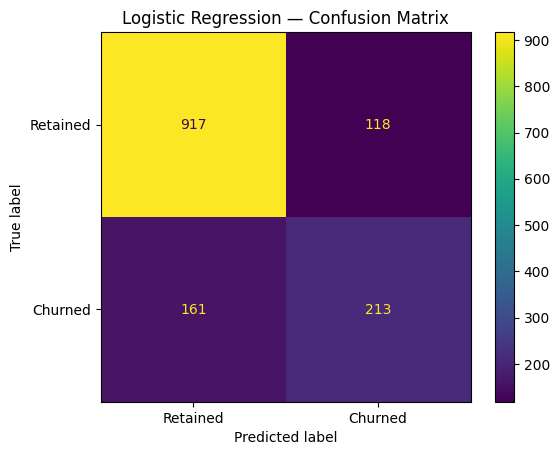

In [280]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_logistic,
    display_labels=["Retained", "Churned"]
)

plt.title("Logistic Regression — Confusion Matrix")
plt.show()

### Confusion Matrix — Interpretation

For churn prediction, false negatives are particularly important because they represent customers who actually churned but were not identified by the model. These customers could be missed by retention campaigns.

## 23. Logistic Regression ROC Curve

The Receiver Operating Characteristic (ROC) curve shows how the Logistic Regression model performs across different classification thresholds.

The Area Under the Curve (ROC-AUC) summarizes the model's ability to distinguish between customers who churn and customers who remain. A higher AUC indicates better discriminatory performance.

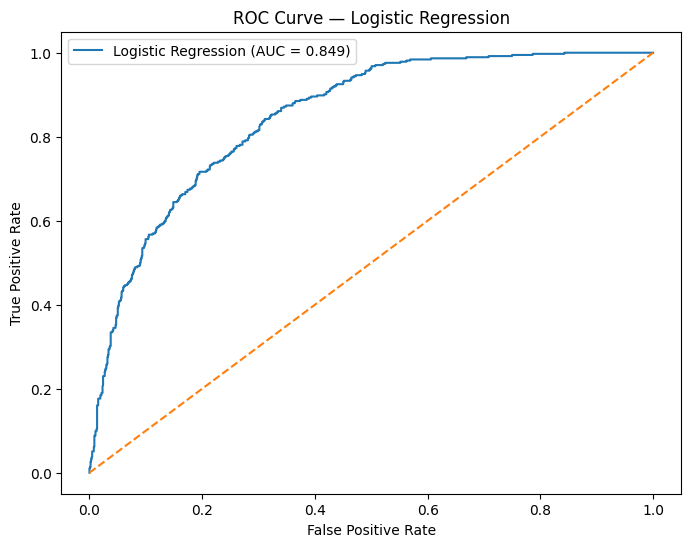

In [281]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_prob_logistic)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Logistic Regression")
plt.legend()
plt.show()

### ROC Curve — Interpretation

The ROC-AUC score of approximately 0.85 indicates that the Logistic Regression model has good ability to distinguish between churned and retained customers. This provides a useful baseline for evaluating more complex models.

## 24. Decision Tree Model

A Decision Tree Classifier will be trained to predict customer churn.

Decision Trees can capture non-linear relationships and interactions between customer characteristics, services, contracts, and billing information. The model will provide a useful comparison with the Logistic Regression baseline.

In [282]:
from sklearn.tree import DecisionTreeClassifier

In [283]:
decision_tree = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

In [284]:
decision_tree.fit(X_train_processed, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

In [285]:
y_pred_tree = decision_tree.predict(X_test_processed)

In [286]:
y_prob_tree = decision_tree.predict_proba(X_test_processed)[:, 1]

### Decision Tree Training

The Decision Tree has been trained using the same training data and preprocessing pipeline as the Logistic Regression model. Its predictions will be evaluated using the same metrics so that the models can be compared fairly.

## 25. Decision Tree Evaluation

The Decision Tree will be evaluated using Accuracy, Precision, Recall, F1-score, and ROC-AUC.

Using the same evaluation metrics as the Logistic Regression baseline allows us to determine whether the Decision Tree provides better predictive performance.

In [287]:
tree_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_tree),
    "Precision": precision_score(y_test, y_pred_tree),
    "Recall": recall_score(y_test, y_pred_tree),
    "F1-Score": f1_score(y_test, y_pred_tree),
    "ROC-AUC": roc_auc_score(y_test, y_prob_tree)
}

tree_metrics

{'Accuracy': 0.794180269694819,
 'Precision': 0.6160220994475138,
 'Recall': 0.5962566844919787,
 'F1-Score': 0.6059782608695652,
 'ROC-AUC': 0.8352863675114315}

In [288]:
tree_results = pd.DataFrame(
    [tree_metrics],
    index=["Decision Tree"]
)

tree_results

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Decision Tree,0.79418,0.616022,0.596257,0.605978,0.835286


In [289]:
model_results = pd.concat([
    logistic_results,
    tree_results
])

model_results

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression,0.801987,0.643505,0.569519,0.604255,0.848867
Decision Tree,0.794180,0.616022,0.596257,0.605978,0.835286


### Decision Tree — Initial Comparison

The Decision Tree results can now be compared with the Logistic Regression baseline. The comparison focuses particularly on Recall, F1-score, and ROC-AUC because correctly identifying customers at risk of churn is important for targeted retention efforts.

## 26. Random Forest Model

A Random Forest classifier will be trained as an ensemble model.

Random Forest combines multiple decision trees to improve predictive stability and reduce the risk of relying on a single tree's decisions. Its performance will be compared with Logistic Regression and the Decision Tree.

In [290]:
from sklearn.ensemble import RandomForestClassifier

In [291]:
random_forest = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42,
    n_jobs=-1
)

In [292]:
random_forest.fit(X_train_processed, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total nu

In [293]:
y_pred_rf = random_forest.predict(X_test_processed)

In [294]:
y_prob_rf = random_forest.predict_proba(X_test_processed)[:, 1]

### Random Forest Training

The Random Forest model has been trained using the same training data and preprocessing pipeline used for the previous models. Predictions and churn probabilities have been generated for the unseen test set.

## 27. Random Forest Evaluation

The Random Forest model will be evaluated using Accuracy, Precision, Recall, F1-score, and ROC-AUC.

These results will be compared with the Logistic Regression and Decision Tree models to determine which model provides the strongest overall churn prediction performance.

In [295]:
rf_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Precision": precision_score(y_test, y_pred_rf),
    "Recall": recall_score(y_test, y_pred_rf),
    "F1-Score": f1_score(y_test, y_pred_rf),
    "ROC-AUC": roc_auc_score(y_test, y_prob_rf)
}

rf_metrics

{'Accuracy': 0.8069552874378992,
 'Precision': 0.6677631578947368,
 'Recall': 0.5427807486631016,
 'F1-Score': 0.5988200589970502,
 'ROC-AUC': 0.8534488103541812}

In [296]:
rf_results = pd.DataFrame(
    [rf_metrics],
    index=["Random Forest"]
)

rf_results

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Random Forest,0.806955,0.667763,0.542781,0.59882,0.853449


In [297]:
model_results = pd.concat([
    logistic_results,
    tree_results,
    rf_results
])

model_results

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression,0.801987,0.643505,0.569519,0.604255,0.848867
Decision Tree,0.794180,0.616022,0.596257,0.605978,0.835286
Random Forest,0.806955,0.667763,0.542781,0.598820,0.853449


### Random Forest — Initial Comparison

The Random Forest results are now included alongside the Logistic Regression and Decision Tree models.

The final model selection will consider not only overall accuracy but also Recall, F1-score, and ROC-AUC, since identifying customers at risk of churn is a key business objective.

## 28. Final Model Comparison

The three classification models are compared using Accuracy, Precision, Recall, F1-score, and ROC-AUC.

Because the business objective is to identify customers at risk of churn, Recall and F1-score are important. ROC-AUC and overall predictive performance are also considered when selecting the final model.

In [298]:
model_results.sort_values(
    by="ROC-AUC",
    ascending=False
)

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Random Forest,0.806955,0.667763,0.542781,0.598820,0.853449
Logistic Regression,0.801987,0.643505,0.569519,0.604255,0.848867
Decision Tree,0.794180,0.616022,0.596257,0.605978,0.835286


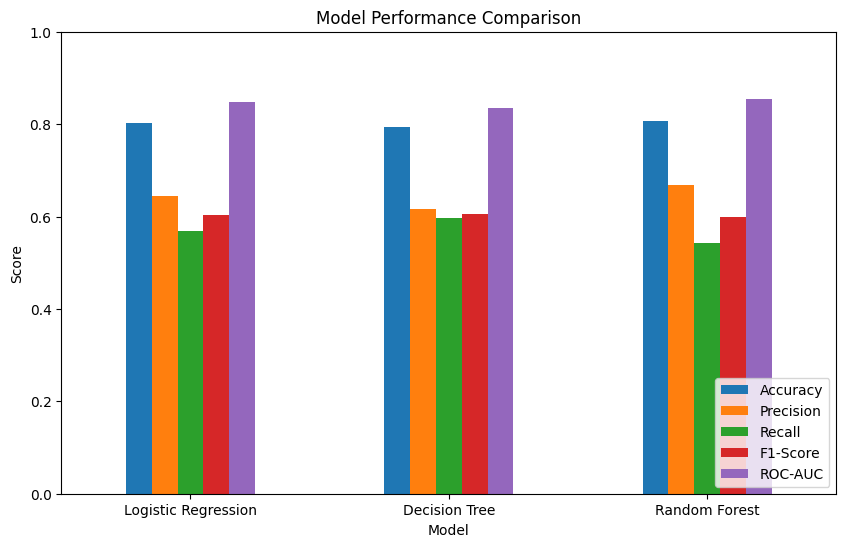

In [299]:
model_results.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.show()

### Model Selection

Random Forest achieves the highest ROC-AUC (0.853) and the highest precision (0.668), while Logistic Regression provides a strong and highly interpretable baseline. The Decision Tree achieves the highest recall (0.596).

For the final churn prediction model, Random Forest will be selected because it provides the strongest overall discriminatory performance and the highest ROC-AUC among the evaluated models. However, the relatively lower recall indicates that further threshold tuning could be considered if the business prioritizes identifying as many potential churners as possible.

## 29. Feature Importance

Random Forest feature importance is used to identify the variables that contribute most to the model's churn predictions. These insights can help translate the machine learning results into actionable customer-retention strategies.

In [300]:
feature_names = preprocessor.get_feature_names_out()

feature_importance = pd.Series(
    random_forest.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

feature_importance.head(15)

num__Tenure Months                      0.121193
cat__Contract_Month-to-month            0.114841
num__Total Charges                      0.095274
cat__Online Security_No                 0.061024
num__Monthly Charges                    0.060522
cat__Internet Service_Fiber optic       0.054783
cat__Contract_Two year                  0.048179
cat__Tech Support_No                    0.047290
cat__Dependents_Yes                     0.044078
cat__Payment Method_Electronic check    0.041718
cat__Dependents_No                      0.040143
cat__Internet Service_DSL               0.022692
cat__Online Backup_No                   0.019232
cat__Contract_One year                  0.019087
cat__Online Security_Yes                0.016686
dtype: float64

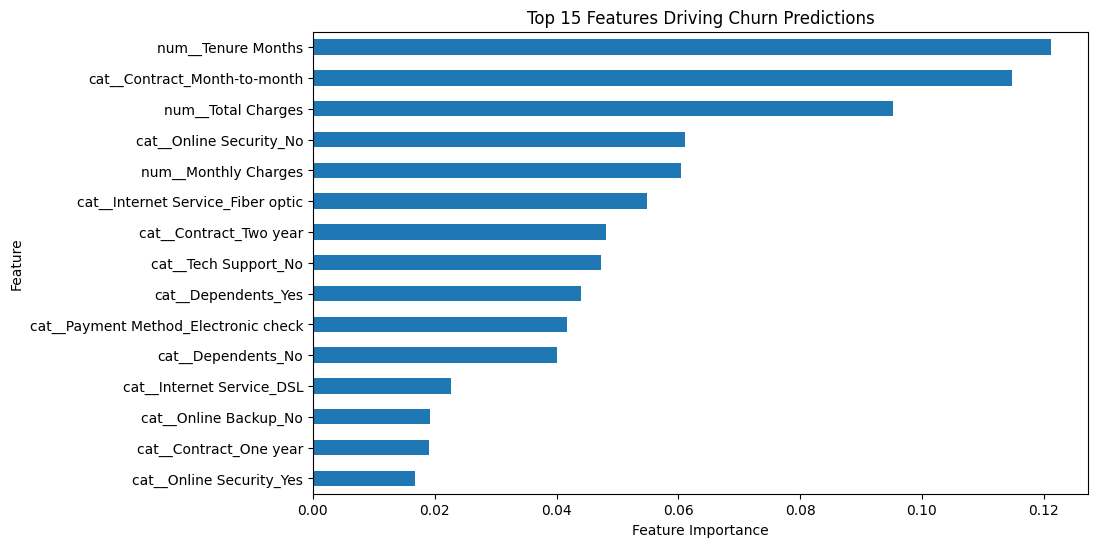

In [301]:
plt.figure(figsize=(10, 6))

feature_importance.head(15).sort_values().plot(
    kind="barh"
)

plt.title("Top 15 Features Driving Churn Predictions")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.show()

### Feature Importance — Interpretation

The most important features identified by the Random Forest provide insight into the characteristics associated with customer churn. These findings can be used to prioritize retention efforts toward customers with higher-risk characteristics.

## 30. Business Recommendations

Based on the exploratory analysis and machine learning results, the following retention strategies are recommended:

1. **Target month-to-month customers:** Month-to-month contracts show substantially higher churn than longer-term contracts. Incentives for annual or two-year contracts could improve retention.

2. **Focus on high-risk internet-service customers:** Fiber-optic customers show a notably higher churn rate and should receive targeted retention offers and service-quality interventions.

3. **Prioritize customers with high recurring charges:** Customers with higher monthly charges show greater churn risk, suggesting that pricing, perceived value, and plan optimization should be reviewed.

4. **Strengthen support and security services:** Customers without services such as online security and technical support show higher churn rates, making bundled service offers a potential retention strategy.

5. **Use predictive targeting:** The Random Forest model can be used to identify customers with high churn probability so retention campaigns can be prioritized.

6. **Optimize the prediction threshold:** Because the current Random Forest recall is relatively modest, future iterations could lower the classification threshold to identify more potential churners when the cost of missing a churner is high.

# Project Conclusion

This project analyzed customer churn patterns and developed machine learning models to predict customers at risk of leaving.

Three classification models were evaluated: Logistic Regression, Decision Tree, and Random Forest. Random Forest achieved the strongest overall ROC-AUC performance at approximately 0.85, while the Decision Tree achieved the highest recall.

The analysis demonstrates how customer demographics, tenure, services, contracts, and billing characteristics can be combined with machine learning to support proactive customer-retention decisions.